<a href="https://colab.research.google.com/github/Rafhaeloktafandhi/Analisis-runtun-waktu/blob/main/Praktikum_ARW_3_Deep_Learning_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Runtun Waktu

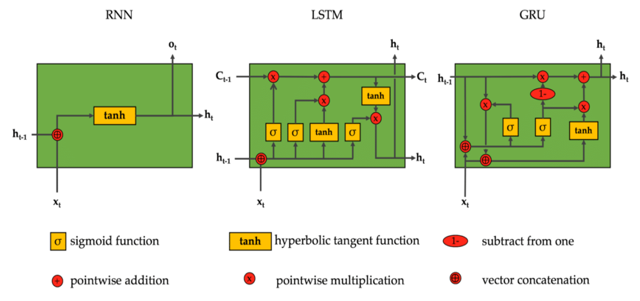

#Persiapan Library & Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
plt.rcParams['figure.figsize'] = 12, 6            #agar semua plot ukurannya sama
from scipy import stats
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from dateutil.relativedelta import relativedelta
from pandas import Timestamp
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, RNN, LSTM, GRU, SimpleRNN
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
import random

#agar hasilnya tetap sama ketika diulang
SEED = 42
os.environ["PYTHONHASHSEED"]        = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]  = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

random.seed(SEED)           # random bawaan Python
np.random.seed(SEED)        # NumPy
tf.random.set_seed(SEED)    # TensorFlow / Keras

In [2]:
#Download data
!wget https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv

--2026-06-26 01:13:30--  https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1746 (1.7K) [text/plain]
Saving to: ‘AirPassengers.csv’

AirPassengers.csv   100%[===================>]   1.71K  --.-KB/s    in 0s      

2026-06-26 01:13:30 (30.7 MB/s) - ‘AirPassengers.csv’ saved [1746/1746]



In [3]:
#Load data
data_passenger = pd.read_csv('AirPassengers.csv')
data_passenger

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


# Preprocessing

In [4]:
#Mengubah tanggal menjadi index
data_passenger['Month']=pd.to_datetime(data_passenger['Month'])
data_passenger.set_index('Month', inplace=True)
#check datatype of index
data_passenger.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

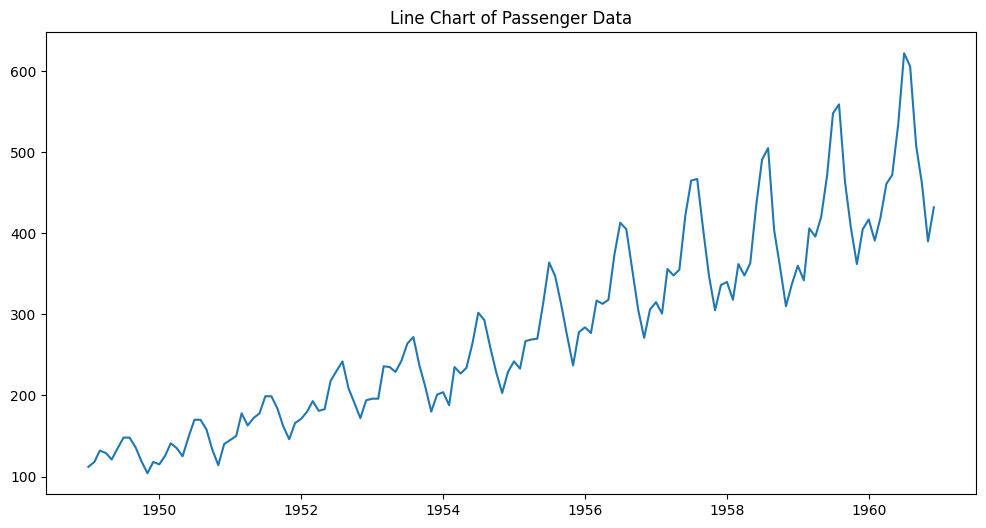

In [5]:
#Plot line chart
plt.plot(data_passenger)
plt.title('Line Chart of Passenger Data')
plt.show()

## Membagi data menjadi training & testing

In [6]:
#Menentukan data training dan testing

train_size = int(len(data_passenger)*0.7)         #70% data pertama menjadi data training
print('Train size: ', train_size)
print('Test size: ', len(data_passenger)-train_size)
train, test = data_passenger[:train_size], data_passenger[train_size:]

Train size:  100
Test size:  44


## Scaling dataset
Bagian ini sebenarnya tidak wajib, tapi semacam "best practice" untuk memudahkan komputasi

In [7]:
# Scaling the training and test data
scaler = MinMaxScaler().fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

 ## Membuat fungsi sliding window
Selanjutnya kita akan membuat fungsi sliding window, misalkan window size = w, maka model akan mengikuti :

$x_t = f(x_{t-1}, ..., x_{t-w})$


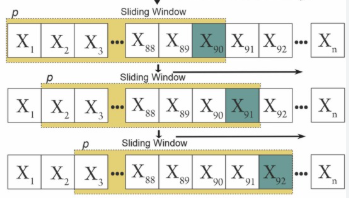

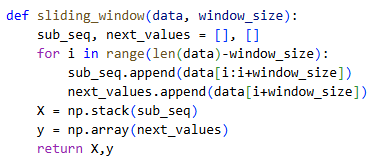

In [9]:
def sliding_window(data, window_size):
    sub_seq, next_values = [], []
    for i in range(len(data)-window_size):
        sub_seq.append(data[i:i+window_size])
        next_values.append(data[i+window_size])
    X = np.stack(sub_seq)
    y = np.array(next_values)
    return X,y

window_size = 12
X_train, y_train = sliding_window(scaled_train, window_size)
X_test, y_test = sliding_window(scaled_test, window_size)


# Training model


Arsitektur yang digunakan bisa disesuaikan. Pada contoh ini:

**1. Input Layer**
* Pasangan data ke-t dan 12 data periode sebelum t

**2. Hidden Layer**
* Misalkan **unit=m**, artinya RNN/LSTM/GRU merangkum pola historis menjadi **m** feature
* Misalkan layer selanjutnya Dense(**n1**), artinya mengekstrak hubungan non-linear dari **m** feature sebelumnya menjadi **n1** feature baru
* Misalkan layer selanjutnya Dense(**n2**), artinya mengekstrak hubungan non-linear dari **n1** feature sebelumnya menjadi **n2** feature baru, begitu seterusnya
* Dropout : optional, tujuannya mencegah overfitting, umumnya 0.1 - 0.2 (maksudnya mengurangi 10%-20% dari jumlah neuron yang ada saat ini secara acak)

pilihan angka **m, n1,n2, dst bebas asal m > n1 > n2 >...dst**, tapi pada umumnya bilangan pangkat 2 (128, 64, 32, 16, 8, 4) untuk mengoptimalkan GPU & memori komputer. Activation bisa relu atau tanh.

Lapisan neuron di hidden layer bisa ditambahkan, terutama jika datanya banyak. Untuk LSTM dan GRU proses "gate" sudah otomatis terjadi saat pengurangan jumlah feature di hidden layer.

**3. Output Layer**
* Dense(1) menghasilkan prediksi data ke-t

Hasil prediksi data ke-t dan data asli ke-t dievaluasi oleh loss function-nya. Setelah itu, optimizer akan mengupdate bobot-bobot feature di hidden layer untuk meminimalisir loss function ini.

Loss function & metrics yang digunakan : bisa mse, mae, rmse, mape karena datanya numerik

optimizer : Adam, SGD, RMSProp. learning rate: seberapa besar model belajar, bisa misalnya : 0.01, 0.001, 0.0005, 3e-4, 2e-3, dst


In [ ]:
def create_model(unit=128, dropout=0.2, window_size=12):                  #dropout optional, bisa dihapus saja jika tidak mau digunakan
    # create model
    model = Sequential()
    model.add(GRU(units=unit, input_shape=(window_size, 1)))              #Pilih salah satu : SimpleRNN/LSTM/GRU
    #model.add(Dense(64))                                                #optional, boleh ditambah sebanyak mungkin, bisa juga dihilangkan
    #model.add(Dense(32))                                                #optional, boleh ditambah sebanyak mungkin, bisa juga dihilangkan
    ...
    model.add(Dense(8, activation="tanh"))
    #model.add(Dropout(dropout, seed=SEED))                             #optional
    model.add(Dense(1))
    # Compile model
    model.compile(loss="mse", optimizer=Adam(learning_rate=0.001), metrics=["mse"])
    return model

model = create_model(window_size)
model.summary()

Epoch=berapa kali iterasi training

Optional : Early stopping patience =15, artinya proses training berhenti kalo validation loss tidak menurun di 15 epoch terakhir, tujuannya mencegah overfitting. Tidak harus 15, selama < epoch, ga pake early stopping juga ga masalah.

batch size= jumlah data dalam 1 kelompok batch saat training, karena kita melakukan training secara parallel (semakin besar ukuran batch proses training semakin cepat). Biasanya 4, 16, 32, dst

In [ ]:
callbacks = [
#    EarlyStopping(monitor="val_loss", mode = "min", patience = 15, restore_best_weights=True),      #optional
    ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss")]

EPOCHS     = 100          #misalnya 30, 50, 100, dst
BATCH_SIZE = 16          #misalnya 4, 16, 32, dst

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    shuffle=False,
    callbacks=callbacks,
    verbose=1
)

model tersimpan di file "best_model.keras"

In [ ]:
#Plot Loss Function
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Prediksi
train_predict = model.predict(X_train, verbose=0)
test_predict  = model.predict(X_test,  verbose=0)

# Kembalikan ke skala asli
train_predict = scaler.inverse_transform(train_predict)
test_predict  = scaler.inverse_transform(test_predict)
y_train_orig  = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_orig   = scaler.inverse_transform(y_test.reshape(-1, 1))

print('RMSE train: ', root_mean_squared_error(y_train_orig, train_predict))
print('RMSE test:  ', root_mean_squared_error(y_test_orig, test_predict))
print('MAE train: ', mean_absolute_error(y_train_orig, train_predict))
print('MAE test:  ', mean_absolute_error(y_test_orig, test_predict))
print('MAPE train: ', mean_absolute_percentage_error(y_train_orig, train_predict))
print('MAPE test:  ', mean_absolute_percentage_error(y_test_orig, test_predict))

RMSE train:  18.057706591302473
RMSE test:   37.41050576697794
MAE train:  14.852471958507191
MAE test:   29.215133666992198
MAPE train:  0.06703903693471529
MAPE test:   0.06888865990942317


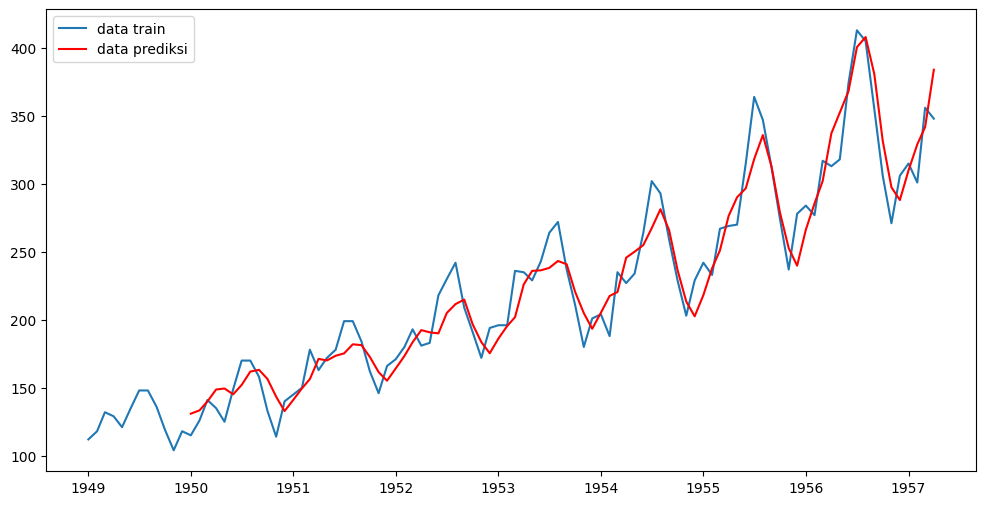

In [ ]:
train_predict_series = pd.Series(train_predict.reshape(1,-1)[0], index=train.index[window_size:])
plt.plot(train, label='data train')
plt.plot(train_predict_series, color='red', label='data prediksi')
plt.legend(loc='best')
plt.show()

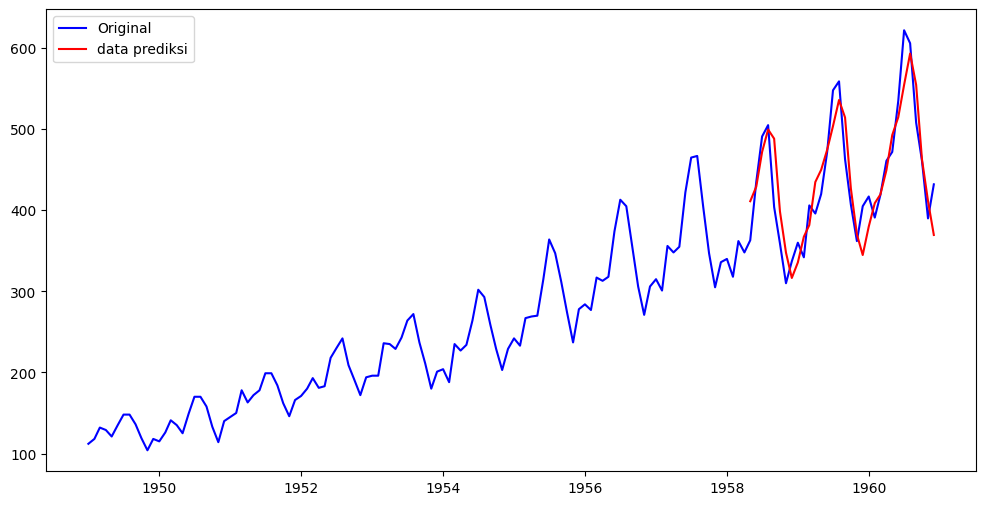

In [ ]:
test_predict_series = pd.Series(test_predict.reshape(1,-1)[0], index=test.index[window_size:])
plt.plot(data_passenger, color='blue',label='Original')
plt.plot(test_predict_series, color='red', label='data prediksi')
plt.legend(loc='best')
plt.show()

# Simpan dan Panggil model

**1. Model Deep Learning**

Model sebelumnya sudah disimpan dengan nama "best_model.keras", silahkan download dan jika ingin digunakan lagi :
`from tensorflow.keras.models import load_model`

`loaded_model = load_model("best_model.keras")`

**2. Model SARIMA**

misalnya `model_fix = model.fit()`, simpan dengan `model_fix.save('model_fix.pkl')`, maka model sudah tersimpan dengan nama model_fix.pkl, silahkan download dan jika ingin digunakan lagi :

`from statsmodels.tsa.arima.model import ARIMAResults`

`loaded_model = ARIMAResults.load("model_fix.pkl")`

In [ ]:
#@title **Forecasting LSTM/RNN/GRU**
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta

dari = '2020-01-01'  #@param {type: "string"}
sampai = '2021-12-31' #@param {type: "string"}

# 1. Hitung berapa langkah (bulan) ke depan yang harus diprediksi
data_terakhir = data_passenger.index[-1]
dari_dt = datetime.strptime(dari, '%Y-%m-%d')
sampai_dt = datetime.strptime(sampai, '%Y-%m-%d')

# Hitung jarak dari data terakhir di dataset sampai tanggal mulai prediksi
diff_dari = relativedelta(dari_dt, data_terakhir)
langkah_ke_awal = diff_dari.years * 12 + diff_dari.months

# Hitung durasi total forecasting (berapa bulan yang mau diprediksi)
diff_total = relativedelta(sampai_dt, data_terakhir)
total_langkah = diff_total.years * 12 + diff_total.months

if total_langkah <= 0:
    raise ValueError("Tanggal 'sampai' harus lebih maju daripada data terakhir di dataset.")

# 2. Ambil 12 data terakhir dari dataset sebagai modal awal LSTM (Window Awal)
# Pastikan data_passenger sudah dalam bentuk ter-scale jika modelmu dilatih dengan data ter-scale
data_terakhir_scaled = scaler.transform(data_passenger.values.reshape(-1, 1))
input_window = data_terakhir_scaled[-window_size:].tolist()

# 3. Proses Forecasting secara Rekursif (Looping)
prediksi_scaled = []

for _ in range(total_langkah):
    # Ubah input_window menjadi bentuk 3D yang diterima LSTM: (batch_size, window_size, fitur) -> (1, 12, 1)
    current_input = np.array(input_window[-window_size:]).reshape(1, window_size, 1)

    # Prediksi 1 titik ke depan
    next_pred = model.predict(current_input, verbose=0)[0][0]

    # Simpan hasil prediksi
    prediksi_scaled.append(next_pred)

    # Masukkan hasil prediksi tadi ke dalam window untuk prediksi berikutnya (geser window)
    input_window.append([next_pred])

# 4. Kembalikan hasil prediksi ke skala asli (Inverse Transform)
prediksi_asli = scaler.inverse_transform(np.array(prediksi_scaled).reshape(-1, 1)).flatten()

# 5. Buat Datetime Index untuk Hasil Prediksi
tgl_prediksi_penuh = pd.date_range(start=data_terakhir + pd.DateOffset(months=1),
                                   periods=total_langkah, freq='ME')

df_forecasting = pd.Series(prediksi_asli, index=tgl_prediksi_penuh)

# 6. Potong hasil prediksi agar HANYA menampilkan rentang 'dari' sampai 'sampai' sesuai parameter
forecasting_tujuan = df_forecasting[dari_dt:sampai_dt]

# 7. Visualisasi
plt.plot(forecasting_tujuan, color='blue', label='Prediksi LSTM')
plt.legend(loc='best')
plt.title(f'Forecasting LSTM {dari} sampai {sampai}')
plt.show()

forecasting_tujuan

